In [1]:
#Dataset Load:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df = df.drop_duplicates()

print("Shape:", df.shape)
df.head()

Shape: (149, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
#Descriptive Statistics:
print("Basic Statistics:")
print(df.describe())

print("\nSpecies Count:")
print(df['species'].value_counts())

Basic Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         149.000000        149.000000         149.000000   
mean            5.843624          3.059732           3.748993   
std             0.830851          0.436342           1.767791   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.300000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        149.000000  
mean           1.194631  
std            0.762622  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

Species Count:
species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64


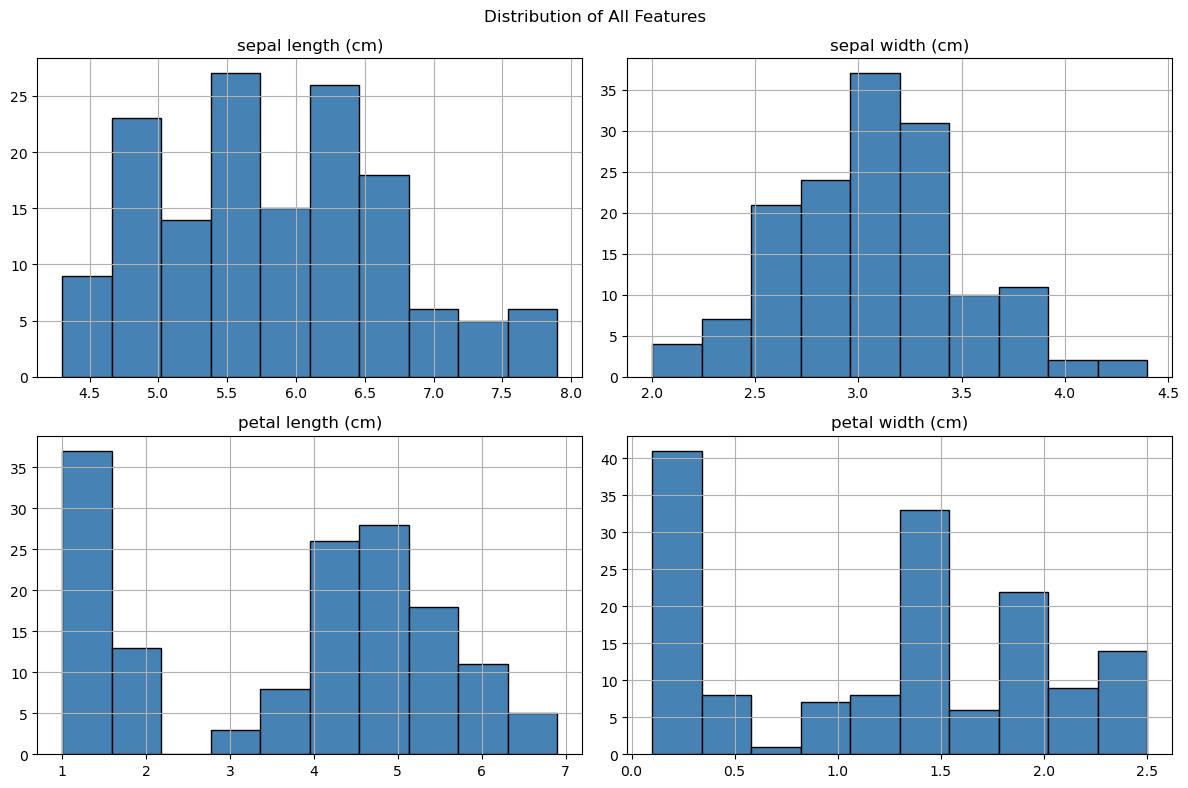

In [3]:
#Histogram
df.hist(figsize=(12,8), color='steelblue', edgecolor='black')
plt.suptitle('Distribution of All Features')
plt.tight_layout()
plt.show()

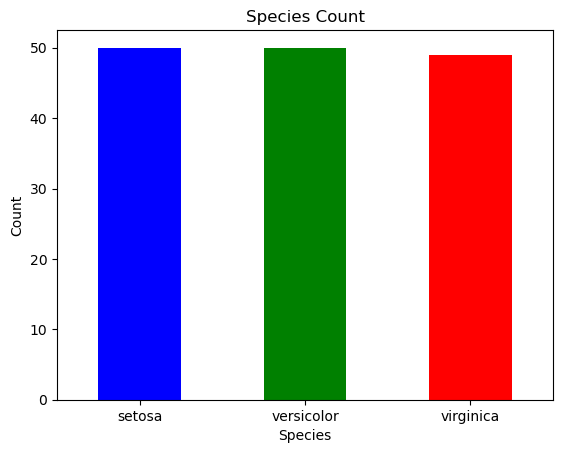

In [4]:
#Bar Chart:
df['species'].value_counts().plot(kind='bar', color=['blue','green','red'])
plt.title('Species Count')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [5]:
#SQL Business Questions:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('iris', conn, index=False)

# Question 1: Average measurements per species
q1 = pd.read_sql_query("""
SELECT species,
ROUND(AVG("sepal length (cm)"),2) as avg_sepal_length,
ROUND(AVG("sepal width (cm)"),2) as avg_sepal_width,
ROUND(AVG("petal length (cm)"),2) as avg_petal_length,
ROUND(AVG("petal width (cm)"),2) as avg_petal_width
FROM iris
GROUP BY species
""", conn)
print("Q1: Average measurements per species")
print(q1)

Q1: Average measurements per species
      species  avg_sepal_length  avg_sepal_width  avg_petal_length  \
0      setosa              5.01             3.43              1.46   
1  versicolor              5.94             2.77              4.26   
2   virginica              6.60             2.98              5.56   

   avg_petal_width  
0             0.25  
1             1.33  
2             2.03  


In [6]:
# More SQL Questions:
# Question 2: Top 5 longest sepal length
q2 = pd.read_sql_query("""
SELECT species, "sepal length (cm)"
FROM iris
ORDER BY "sepal length (cm)" DESC
LIMIT 5
""", conn)
print("Q2: Top 5 longest sepal length")
print(q2)

# Question 3: Species with petal length > 4
q3 = pd.read_sql_query("""
SELECT species, COUNT(*) as count
FROM iris
WHERE "petal length (cm)" > 4
GROUP BY species
""", conn)
print("\nQ3: Species with petal length > 4")
print(q3)

# Question 4: Minimum and Maximum values
q4 = pd.read_sql_query("""
SELECT species,
MIN("petal width (cm)") as min_petal_width,
MAX("petal width (cm)") as max_petal_width
FROM iris
GROUP BY species
""", conn)
print("\nQ4: Min and Max petal width per species")
print(q4)

Q2: Top 5 longest sepal length
     species  sepal length (cm)
0  virginica                7.9
1  virginica                7.7
2  virginica                7.7
3  virginica                7.7
4  virginica                7.7

Q3: Species with petal length > 4
      species  count
0  versicolor     34
1   virginica     49

Q4: Min and Max petal width per species
      species  min_petal_width  max_petal_width
0      setosa              0.1              0.6
1  versicolor              1.0              1.8
2   virginica              1.4              2.5


C:\Users\zerot\AppData\Local\Temp\ipykernel_12776\2711548695.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for species, group in df.groupby('species'):


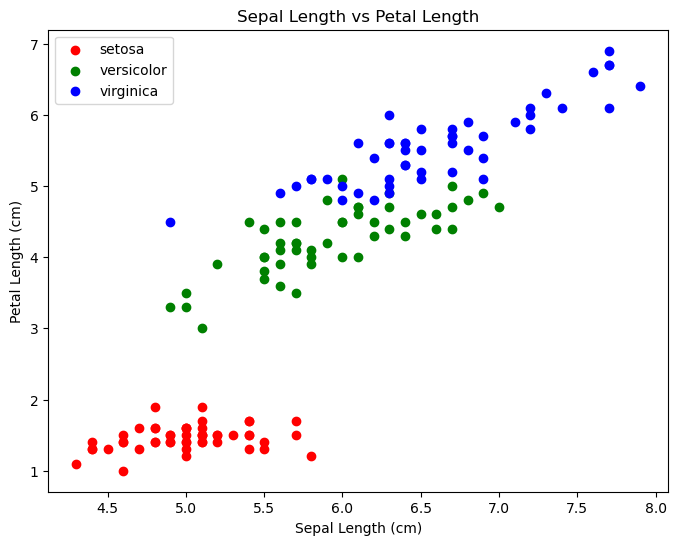

In [7]:
#Scatter Plot:
plt.figure(figsize=(8,6))
colors = {'setosa':'red', 'versicolor':'green', 'virginica':'blue'}
for species, group in df.groupby('species'):
    plt.scatter(group['sepal length (cm)'],
                group['petal length (cm)'],
                label=species,
                color=colors[species])
plt.title('Sepal Length vs Petal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend()
plt.show()

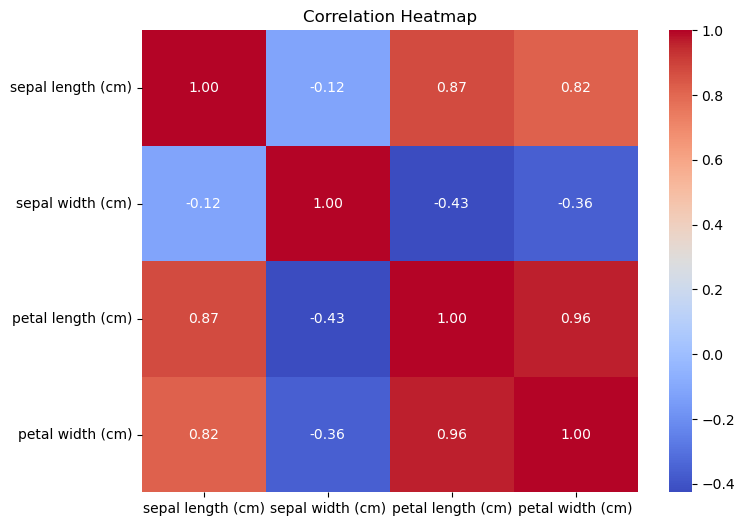

In [8]:
# Heatmap:
plt.figure(figsize=(8,6))
correlation = df.drop('species', axis=1).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

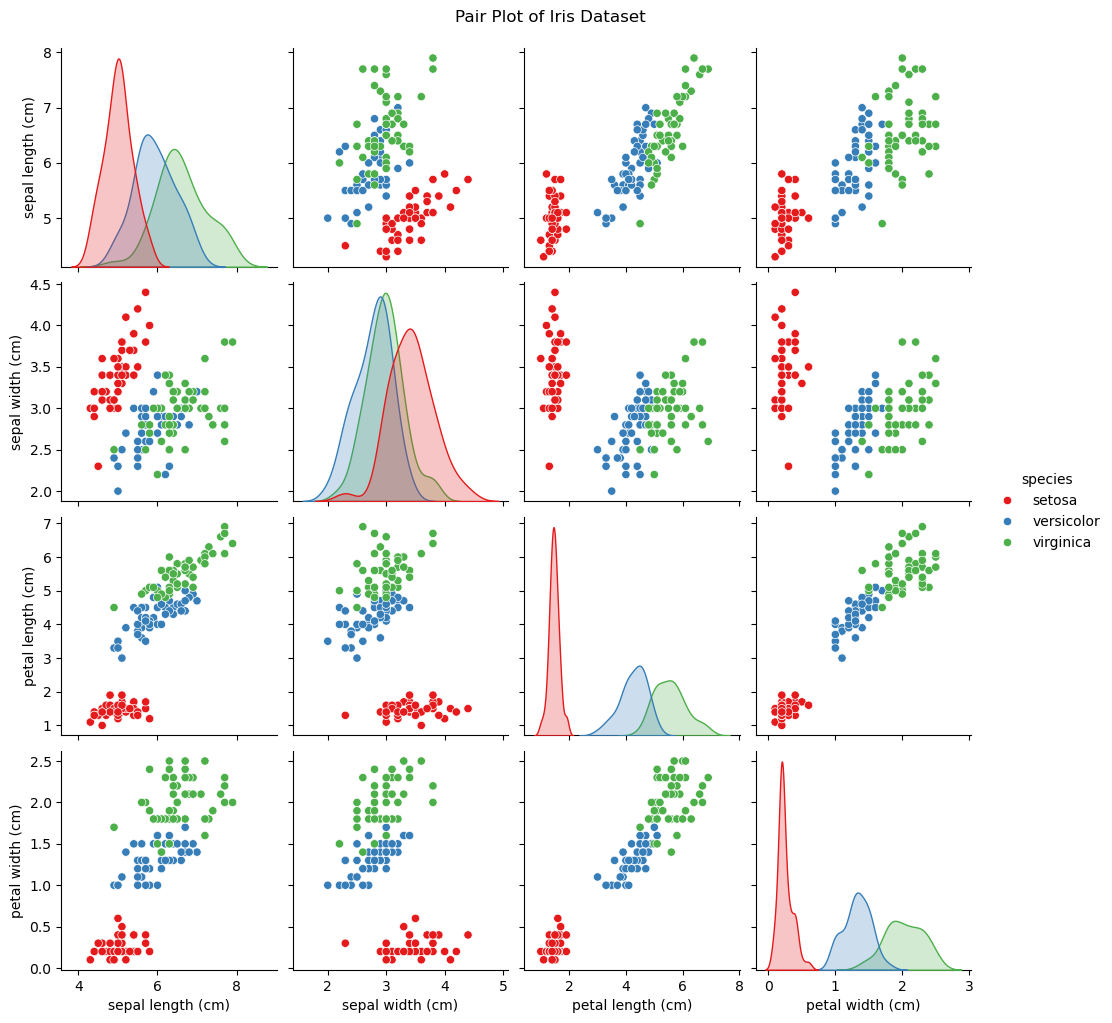

In [9]:
# Pair Plot:
sns.pairplot(df, hue='species', palette='Set1')
plt.suptitle('Pair Plot of Iris Dataset', y=1.02)
plt.show()

In [10]:
# Key Insights:
print("KEY INSIGHTS FROM EDA:")
print("="*40)
print("1. Setosa is clearly separated from other species")
print("2. Petal length and petal width are highly correlated (0.96)")
print("3. Virginica has the largest petal and sepal measurements")
print("4. Versicolor lies between Setosa and Virginica")
print("5. Sepal width has the least correlation with other features")

KEY INSIGHTS FROM EDA:
1. Setosa is clearly separated from other species
2. Petal length and petal width are highly correlated (0.96)
3. Virginica has the largest petal and sepal measurements
4. Versicolor lies between Setosa and Virginica
5. Sepal width has the least correlation with other features
